# Data-Driven Forecasting & Peak Demand Prediction
## Afficionado Coffee Roasters — Jan–Jun 2025


 Install & Import

In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.stattools import adfuller
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import LabelEncoder
import xgboost as xgb
import lightgbm as lgb
from prophet import Prophet

plt.style.use('seaborn-v0_8-whitegrid')
PALETTE = ['#2563EB','#16A34A','#DC2626','#D97706','#7C3AED','#0891B2']
STORES  = ['Lower Manhattan', "Hell's Kitchen", 'Astoria']

##Load & Parse Dataset

In [43]:
df_raw=pd.read_excel('Afficionado Coffee Roasters.xlsx')
print(f'Loaded: {df_raw.shape[0]:,} rows × {df_raw.shape[1]} cols')
print('Columns:', df_raw.columns.tolist())
df_raw.head(3)

Loaded: 149,116 rows × 11 cols
Columns: ['transaction_id', 'year', 'transaction_time', 'transaction_qty', 'store_id', 'store_location', 'product_id', 'unit_price', 'product_category', 'product_type', 'product_detail']


,transaction_id,year,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail
0,1,2025,07:06:11,2,5,Lower Manhattan,32,3.0,Coffee,Gourmet brewed coffee,Ethiopia Rg
1,2,2025,07:08:56,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg
2,3,2025,07:14:04,2,5,Lower Manhattan,59,4.5,Drinking Chocolate,Hot chocolate,Dark chocolate Lg


In [44]:
df = df_raw.copy().sort_values('transaction_id').reset_index(drop=True)

df['hour']   = df['transaction_time'].apply(lambda t: t.hour)
df['minute'] = df['transaction_time'].apply(lambda t: t.minute)

df['_prev_hour'] = df['hour'].shift(1, fill_value=0)
df['_new_day']   = (df['hour'] < df['_prev_hour']).astype(int)
df.loc[0, '_new_day'] = 1
df['day_index'] = df['_new_day'].cumsum() - 1

df['transaction_date'] = pd.Timestamp('2025-01-01') + pd.to_timedelta(df['day_index'], unit='D')

df['transaction_datetime'] = df['transaction_date'] + \
    pd.to_timedelta(df['hour'] * 60 + df['minute'], unit='min')

df['revenue'] = df['transaction_qty'] * df['unit_price']

df['day_of_week'] = df['transaction_date'].dt.dayofweek
df['day_name']    = df['transaction_date'].dt.day_name()
df['month']       = df['transaction_date'].dt.month
df['week']        = df['transaction_date'].dt.isocalendar().week.astype(int)
df['is_weekend']  = df['day_of_week'].isin([5,6]).astype(int)

df.drop(columns=['_prev_hour','_new_day'], inplace=True)

print(f'   Date range : {df["transaction_date"].min().date()} → {df["transaction_date"].max().date()}')
print(f'   Days       : {df["transaction_date"].nunique()}')
print(f'   Stores     : {df["store_location"].unique().tolist()}')
print(f'   Categories : {df["product_category"].nunique()}')
print(f'   Revenue    : ${df["revenue"].sum():,.2f}')
df[['transaction_id','transaction_date','hour','store_location','product_category','revenue']].head()

   Date range : 2025-01-01 → 2025-06-30
   Days       : 181
   Stores     : ['Lower Manhattan', "Hell's Kitchen", 'Astoria']
   Categories : 9
   Revenue    : $698,812.33


,transaction_id,transaction_date,hour,store_location,product_category,revenue
0,1,2025-01-01,7,Lower Manhattan,Coffee,6.0
1,2,2025-01-01,7,Lower Manhattan,Tea,6.2
2,3,2025-01-01,7,Lower Manhattan,Drinking Chocolate,9.0
3,4,2025-01-01,7,Lower Manhattan,Coffee,2.0
4,5,2025-01-01,7,Lower Manhattan,Tea,6.2


## Exploratory Data Analysis (EDA)

In [45]:
print('='*58)
print('  AFFICIONADO COFFEE ROASTERS — EDA SUMMARY')
print('='*58)
print(f'  Total transactions  : {len(df):,}')
print(f'  Total revenue       : ${df["revenue"].sum():,.2f}')
print(f'  Avg order value     : ${df["revenue"].mean():.2f}')
print(f'  Avg qty / txn       : {df["transaction_qty"].mean():.2f}')
print(f'  Price range         : ${df["unit_price"].min():.2f} – ${df["unit_price"].max():.2f}')
print('-'*58)
print('  Revenue by Store:')
for store, rev in df.groupby('store_location')['revenue'].sum().items():
    pct = 100 * rev / df['revenue'].sum()
    print(f'    {store:<22}: ${rev:>10,.2f}  ({pct:.1f}%)')
print('-'*58)
print('  Revenue by Category:')
for cat, rev in df.groupby('product_category')['revenue'].sum().sort_values(ascending=False).items():
    print(f'    {cat:<24}: ${rev:>10,.2f}')
print('='*58)

  AFFICIONADO COFFEE ROASTERS — EDA SUMMARY
  Total transactions  : 149,116
  Total revenue       : $698,812.33
  Avg order value     : $4.69
  Avg qty / txn       : 1.44
  Price range         : $0.80 – $45.00
----------------------------------------------------------
  Revenue by Store:
    Astoria               : $232,243.91  (33.2%)
    Hell's Kitchen        : $236,511.17  (33.8%)
    Lower Manhattan       : $230,057.25  (32.9%)
----------------------------------------------------------
  Revenue by Category:
    Coffee                  : $269,952.45
    Tea                     : $196,405.95
    Bakery                  : $ 82,315.64
    Drinking Chocolate      : $ 72,416.00
    Coffee beans            : $ 40,085.25
    Branded                 : $ 13,607.00
    Loose Tea               : $ 11,213.60
    Flavours                : $  8,408.80
    Packaged Chocolate      : $  4,407.64


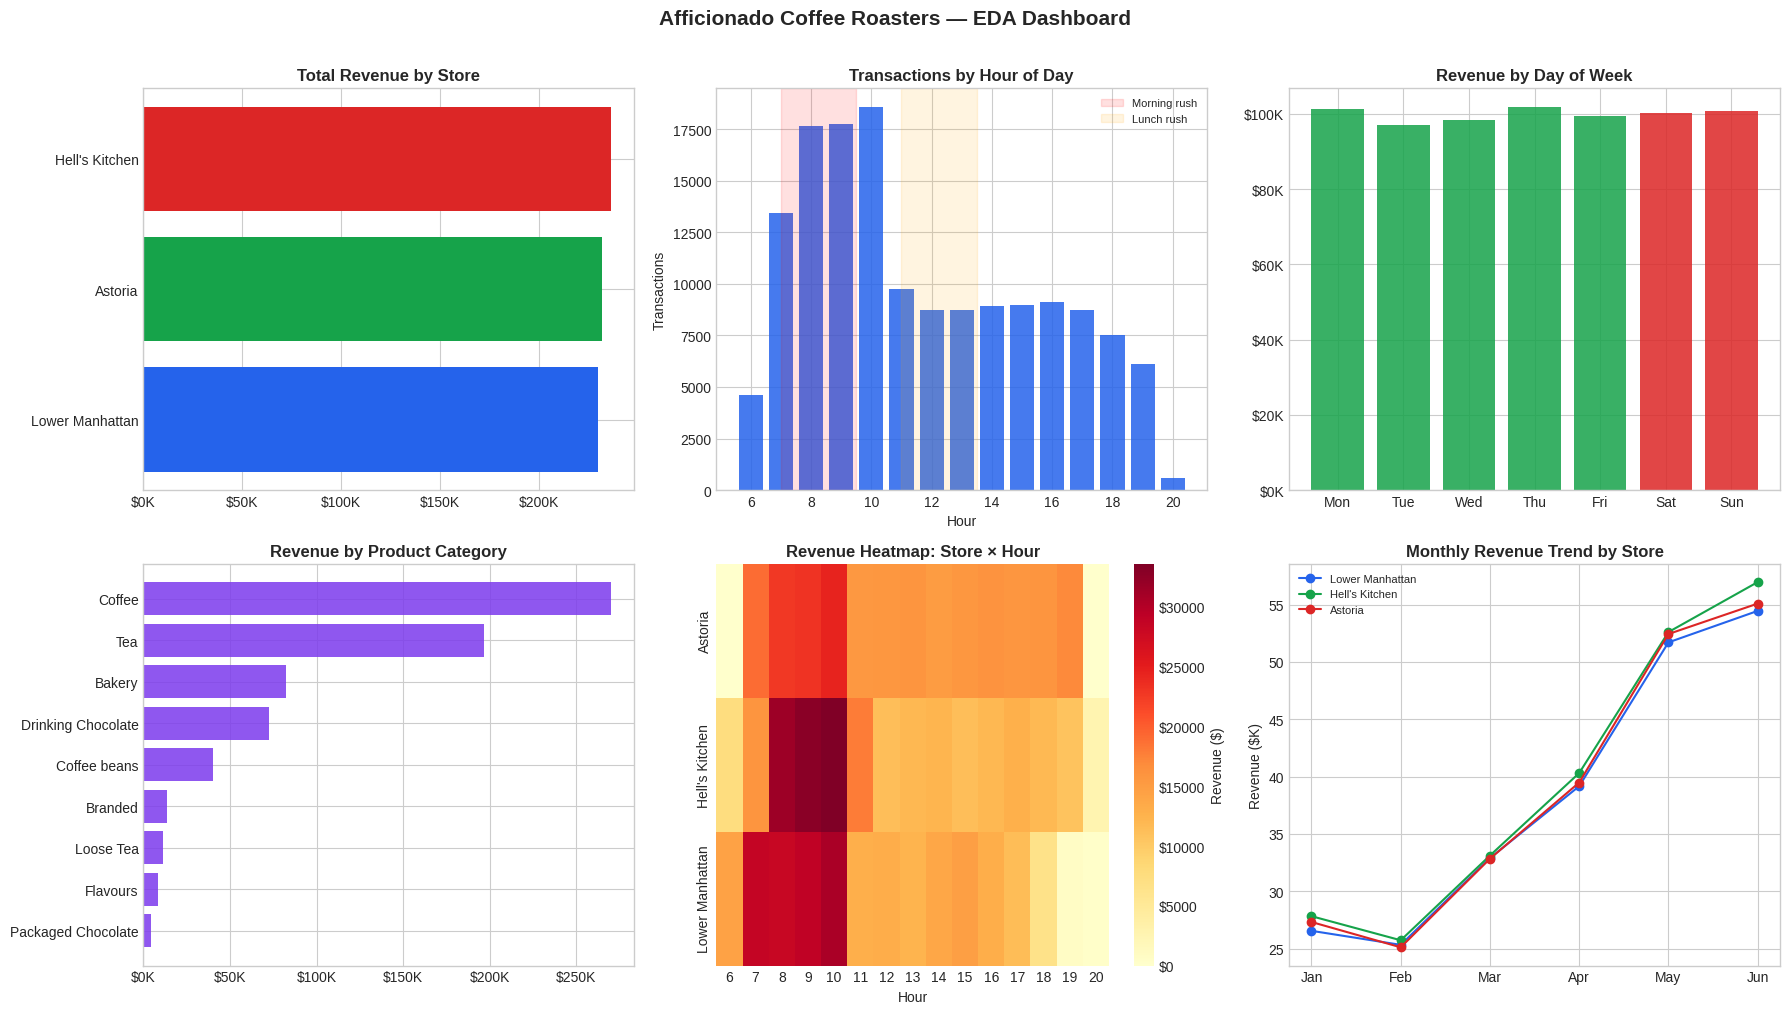

In [46]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Afficionado Coffee Roasters — EDA Dashboard', fontsize=15, fontweight='bold', y=1.01)

store_rev = df.groupby('store_location')['revenue'].sum().sort_values()
axes[0,0].barh(store_rev.index, store_rev.values, color=PALETTE[:3])
axes[0,0].set_title('Total Revenue by Store', fontweight='bold')
axes[0,0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1000:.0f}K'))

hourly_vol = df.groupby('hour')['transaction_id'].count()
bars = axes[0,1].bar(hourly_vol.index, hourly_vol.values, color=PALETTE[0], alpha=0.85)
axes[0,1].axvspan(7, 9.5, alpha=0.12, color='red',    label='Morning rush')
axes[0,1].axvspan(11, 13.5, alpha=0.12, color='orange', label='Lunch rush')
axes[0,1].set_title('Transactions by Hour of Day', fontweight='bold')
axes[0,1].set_xlabel('Hour'); axes[0,1].set_ylabel('Transactions')
axes[0,1].legend(fontsize=8)

dow_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
dow_rev = df.groupby('day_name')['revenue'].sum().reindex(dow_order)
colors_dow = [PALETTE[2] if d in ['Saturday','Sunday'] else PALETTE[1] for d in dow_order]
axes[0,2].bar(range(7), dow_rev.values, color=colors_dow, alpha=0.85)
axes[0,2].set_title('Revenue by Day of Week', fontweight='bold')
axes[0,2].set_xticks(range(7))
axes[0,2].set_xticklabels(['Mon','Tue','Wed','Thu','Fri','Sat','Sun'])
axes[0,2].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1000:.0f}K'))

cat_rev = df.groupby('product_category')['revenue'].sum().sort_values()
axes[1,0].barh(cat_rev.index, cat_rev.values, color=PALETTE[4], alpha=0.85)
axes[1,0].set_title('Revenue by Product Category', fontweight='bold')
axes[1,0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1000:.0f}K'))

heat = df.groupby(['store_location','hour'])['revenue'].sum().unstack(fill_value=0)
sns.heatmap(heat, ax=axes[1,1], cmap='YlOrRd',
            cbar_kws={'label':'Revenue ($)', 'format':'${x:.0f}'})
axes[1,1].set_title('Revenue Heatmap: Store × Hour', fontweight='bold')
axes[1,1].set_xlabel('Hour'); axes[1,1].set_ylabel('')

monthly = df.groupby(['month','store_location'])['revenue'].sum().reset_index()
month_names = {1:'Jan',2:'Feb',3:'Mar',4:'Apr',5:'May',6:'Jun'}
for i, store in enumerate(STORES):
    s = monthly[monthly['store_location']==store]
    axes[1,2].plot(s['month'].map(month_names), s['revenue']/1000,
                   marker='o', label=store, color=PALETTE[i])
axes[1,2].set_title('Monthly Revenue Trend by Store', fontweight='bold')
axes[1,2].set_ylabel('Revenue ($K)')
axes[1,2].legend(fontsize=8)

plt.tight_layout()
plt.show()

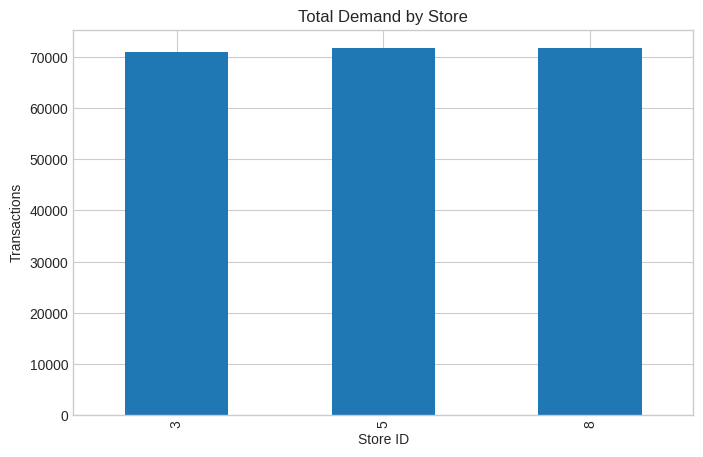

In [47]:
#Store Demand Comparison
store_forecast = df.groupby('store_id')['transaction_qty'].sum()
plt.figure(figsize=(8,5))
store_forecast.plot(kind='bar')
plt.title("Total Demand by Store")
plt.xlabel("Store ID")
plt.ylabel("Transactions")
plt.show()

In [48]:
daily_store = df.groupby(['transaction_date','store_location'])['revenue'].sum().reset_index()

fig = px.line(daily_store, x='transaction_date', y='revenue', color='store_location',
              title='Daily Revenue by Store (Jan–Jun 2025)',
              labels={'revenue':'Revenue ($)','transaction_date':'Date','store_location':'Store'},
              color_discrete_sequence=PALETTE)
fig.update_layout(hovermode='x unified', height=420)
fig.show()

## Time-Series Construction

In [49]:
# (A) Daily revenue & qty per store  — PRIMARY forecasting target
daily_ts = df.groupby(['transaction_date','store_location']).agg(
    daily_revenue =('revenue','sum'),
    daily_qty     =('transaction_qty','sum'),
    daily_txn     =('transaction_id','count')
).reset_index()

all_dates  = pd.date_range(daily_ts['transaction_date'].min(),
                            daily_ts['transaction_date'].max(), freq='D')
full_idx   = pd.MultiIndex.from_product([all_dates, STORES],
                                         names=['transaction_date','store_location'])
daily_ts   = (daily_ts.set_index(['transaction_date','store_location'])
                       .reindex(full_idx, fill_value=0)
                       .reset_index())

# (B) Hourly volume per store
hourly_ts = df.groupby(['transaction_date','hour','store_location']).agg(
    hourly_revenue=('revenue','sum'),
    hourly_qty    =('transaction_qty','sum')
).reset_index()

# (C) Category-level daily demand
cat_ts = df.groupby(['transaction_date','product_category']).agg(
    daily_revenue=('revenue','sum'),
    daily_qty    =('transaction_qty','sum')
).reset_index()

print(f' Daily (store):    {daily_ts.shape}  — {daily_ts["transaction_date"].nunique()} days × {daily_ts["store_location"].nunique()} stores')
print(f' Hourly (store):   {hourly_ts.shape}')
print(f' Category daily:   {cat_ts.shape}')
daily_ts.head(6)

 Daily (store):    (543, 5)  — 181 days × 3 stores
 Hourly (store):   (6863, 5)
 Category daily:   (1373, 4)


,transaction_date,store_location,daily_revenue,daily_qty,daily_txn
0,2025-01-01,Lower Manhattan,788.35,255,176
1,2025-01-01,Hell's Kitchen,851.45,270,184
2,2025-01-01,Astoria,868.40,277,190
3,2025-01-02,Lower Manhattan,649.05,217,159
4,2025-01-02,Hell's Kitchen,828.80,272,195
5,2025-01-02,Astoria,925.50,301,212


In [50]:
print('Augmented Dickey-Fuller Test — Daily Revenue per Store')
print('-'*55)
for store in STORES:
    series = daily_ts[daily_ts['store_location']==store]['daily_revenue'].values
    adf_result = adfuller(series, autolag='AIC')
    status = 'Stationary' if adf_result[1] < 0.05 else 'Non-Stationary (differencing may help)'
    print(f'  {store:<22}: ADF={adf_result[0]:>7.3f}  p={adf_result[1]:.4f}  {status}')

Augmented Dickey-Fuller Test — Daily Revenue per Store
-------------------------------------------------------
  Lower Manhattan       : ADF=  0.108  p=0.9666  Non-Stationary (differencing may help)
  Hell's Kitchen        : ADF= -1.941  p=0.3131  Non-Stationary (differencing may help)
  Astoria               : ADF= -0.007  p=0.9579  Non-Stationary (differencing may help)


## Feature Engineering

In [51]:
TARGET = 'daily_revenue'

def add_features(ts, target=TARGET):
    df_f = ts.sort_values(['store_location','transaction_date']).copy()
    g = df_f.groupby('store_location')[target]


    df_f['lag_1']  = g.shift(1)
    df_f['lag_7']  = g.shift(7)
    df_f['lag_14'] = g.shift(14)
    df_f['lag_28'] = g.shift(28)


    df_f['roll_3']  = g.transform(lambda x: x.shift(1).rolling(3,  min_periods=1).mean())
    df_f['roll_7']  = g.transform(lambda x: x.shift(1).rolling(7,  min_periods=1).mean())
    df_f['roll_14'] = g.transform(lambda x: x.shift(1).rolling(14, min_periods=1).mean())


    df_f['roll_7_std'] = g.transform(lambda x: x.shift(1).rolling(7, min_periods=2).std())


    df_f['dow']        = df_f['transaction_date'].dt.dayofweek
    df_f['month']      = df_f['transaction_date'].dt.month
    df_f['week']       = df_f['transaction_date'].dt.isocalendar().week.astype(int)
    df_f['is_weekend'] = df_f['dow'].isin([5,6]).astype(int)
    df_f['is_monday']  = (df_f['dow']==0).astype(int)
    df_f['is_friday']  = (df_f['dow']==4).astype(int)


    le = LabelEncoder()
    df_f['store_enc'] = le.fit_transform(df_f['store_location'])

    return df_f.dropna(subset=['lag_1','lag_7'])

daily_fe = add_features(daily_ts)

FEATURE_COLS = ['lag_1','lag_7','lag_14','lag_28',
                'roll_3','roll_7','roll_14','roll_7_std',
                'dow','month','week','is_weekend',
                'is_monday','is_friday','store_enc']

print(f' Feature engineering done. Dataset: {daily_fe.shape}')
daily_fe[['transaction_date','store_location',TARGET,'lag_1','lag_7','roll_7','is_weekend']].head(9)

 Feature engineering done. Dataset: (522, 20)


,transaction_date,store_location,daily_revenue,lag_1,lag_7,roll_7,is_weekend
23,2025-01-08,Astoria,793.15,807.30,868.40,847.328571,0
26,2025-01-09,Astoria,774.01,793.15,925.50,836.578571,0
29,2025-01-10,Astoria,947.00,774.01,902.75,814.937143,0
32,2025-01-11,Astoria,740.15,947.00,808.25,821.258571,1
35,2025-01-12,Astoria,660.70,740.15,903.05,811.530000,1
38,2025-01-13,Astoria,705.80,660.70,716.05,776.908571,0
41,2025-01-14,Astoria,763.70,705.80,807.30,775.444286,0
44,2025-01-15,Astoria,1348.93,763.70,793.15,769.215714,0
47,2025-01-16,Astoria,1027.33,1348.93,774.01,848.612857,0


##  Train / Test Split

In [52]:
cutoff = daily_fe['transaction_date'].max() - pd.Timedelta(days=30)

train_df = daily_fe[daily_fe['transaction_date'] <= cutoff].copy()
test_df  = daily_fe[daily_fe['transaction_date'] >  cutoff].copy()

X_train, y_train = train_df[FEATURE_COLS].values, train_df[TARGET].values
X_test,  y_test  = test_df[FEATURE_COLS].values,  test_df[TARGET].values

print(f'Train: {train_df["transaction_date"].min().date()} → {train_df["transaction_date"].max().date()}  ({len(train_df)} rows)')
print(f'Test : {test_df["transaction_date"].min().date()}  → {test_df["transaction_date"].max().date()}  ({len(test_df)} rows)')

Train: 2025-01-08 → 2025-05-31  (432 rows)
Test : 2025-06-01  → 2025-06-30  (90 rows)


## Forecasting Models

In [53]:
all_results = []

def evaluate(y_true, y_pred, name):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-9))) * 100
    acc  = max(0, 100 - mape)

    p80   = np.percentile(y_true, 80)
    mask  = y_true >= p80
    if mask.sum() > 0:
        pk_err = np.mean(np.abs(y_true[mask]-y_pred[mask])/(y_true[mask]+1e-9) > 0.2)*100
    else:
        pk_err = 0.0

    row = {'Model':name,'MAE':mae,'RMSE':rmse,'MAPE%':mape,'Accuracy%':acc,'PeakErrRate%':pk_err,'preds':y_pred}
    all_results.append(row)
    print(f'  {name:<32} | MAE={mae:>7.2f} | RMSE={rmse:>7.2f} | MAPE={mape:>5.2f}% | PeakErr={pk_err:.1f}%')
    return row

print(f'  {"Model":<32} | {"MAE":>7} | {"RMSE":>7} | {"MAPE":>6} | PeakErr')
print('-'*75)

  Model                            |     MAE |    RMSE |   MAPE | PeakErr
---------------------------------------------------------------------------


In [54]:
print('\n BASELINE MODELS')
print('-'*75)

naive_pred = np.full(len(y_test), y_train[-1])
evaluate(y_test, naive_pred, 'Naive (Last Value)')

ma7_pred = np.full(len(y_test), np.mean(y_train[-7:]))
evaluate(y_test, ma7_pred, 'Moving Average (7-day)')

sn = test_df['lag_7'].values
evaluate(y_test, sn, 'Seasonal Naive (lag-7)')


 BASELINE MODELS
---------------------------------------------------------------------------
  Naive (Last Value)               | MAE= 276.60 | RMSE= 351.13 | MAPE=14.07% | PeakErr=100.0%
  Moving Average (7-day)           | MAE= 238.13 | RMSE= 304.79 | MAPE=12.59% | PeakErr=61.1%
  Seasonal Naive (lag-7)           | MAE= 328.80 | RMSE= 401.16 | MAPE=17.93% | PeakErr=44.4%


{'Model': 'Seasonal Naive (lag-7)',
 'MAE': 328.8028888888889,
 'RMSE': np.float64(401.1560919697524),
 'MAPE%': np.float64(17.9300890484972),
 'Accuracy%': np.float64(82.0699109515028),
 'PeakErrRate%': np.float64(44.44444444444444),
 'preds': array([1628.15, 1826.65, 1661.05, 1612.85, 1637.1 , 1670.95, 1671.11,
        1794.85, 1915.45, 1953.5 , 1760.9 , 1842.45, 1397.1 , 1555.55,
        2168.68, 1518.48, 1749.45, 1703.65, 1244.6 , 1439.45, 1588.55,
        2373.21, 2229.8 , 2072.65, 2044.88, 2546.43, 1679.38, 1614.25,
        1912.05, 1864.4 , 1597.4 , 1507.3 , 1655.25, 1264.75, 1125.15,
        1432.5 , 1363.75, 1829.2 , 1701.6 , 1612.8 , 1628.9 , 1531.7 ,
        1611.4 , 2045.5 , 2028.11, 2189.6 , 1990.7 , 2002.53, 2106.6 ,
        2534.8 , 2496.61, 1788.18, 1975.95, 2320.1 , 2175.93, 2124.08,
        1885.65, 2303.83, 1557.1 , 1984.08, 2005.3 , 1967.  , 2242.85,
        1461.05, 1197.25, 1732.03, 1649.27, 1602.95, 1439.45, 1600.35,
        1595.35, 1537.  , 1590.4 , 1282.05, 19

In [55]:
print('\n STATISTICAL MODELS')
print('-'*75)

arima_preds, arima_true = [], []
hw_preds    = []
prophet_store_data = {}

for store in STORES:
    tr = train_df[train_df['store_location']==store][TARGET].values
    te = test_df[test_df['store_location']==store][TARGET].values
    n  = len(te)

    try:
        arima_fit = ARIMA(tr, order=(2,1,2)).fit()
        ap = np.clip(arima_fit.forecast(n), 0, None)
    except Exception:
        ap = np.full(n, tr.mean())
    arima_preds.extend(ap)
    arima_true.extend(te)

    try:
        hw_fit = ExponentialSmoothing(tr, trend='add', seasonal='add',
                                       seasonal_periods=7).fit(optimized=True)
        hp = np.clip(hw_fit.forecast(n), 0, None)
    except Exception:
        hp = np.full(n, tr.mean())
    hw_preds.extend(hp)

    store_dates_train = train_df[train_df['store_location']==store]['transaction_date'].values
    store_dates_test  = test_df[test_df['store_location']==store]['transaction_date'].values
    prophet_store_data[store] = {
        'train_ds': store_dates_train, 'train_y': tr,
        'test_ds':  store_dates_test,  'test_y':  te
    }

evaluate(np.array(arima_true), np.array(arima_preds), 'ARIMA(2,1,2)')
evaluate(np.array(arima_true), np.array(hw_preds),    'Holt-Winters (Additive)')


 STATISTICAL MODELS
---------------------------------------------------------------------------
  ARIMA(2,1,2)                     | MAE= 333.96 | RMSE= 426.24 | MAPE=17.10% | PeakErr=88.9%
  Holt-Winters (Additive)          | MAE= 315.72 | RMSE= 404.76 | MAPE=16.25% | PeakErr=83.3%


{'Model': 'Holt-Winters (Additive)',
 'MAE': 315.7172621425742,
 'RMSE': np.float64(404.7582172546112),
 'MAPE%': np.float64(16.250433998270918),
 'Accuracy%': np.float64(83.74956600172908),
 'PeakErrRate%': np.float64(83.33333333333334),
 'preds': array([1668.87595501, 1646.2000897 , 1700.62814563, 1622.73388792,
        1746.86016064, 1630.44762991, 1694.07171486, 1703.06841701,
        1680.3925517 , 1734.82060763, 1656.92634992, 1781.05262264,
        1664.64009191, 1728.26417686, 1737.26087901, 1714.5850137 ,
        1769.01306963, 1691.11881192, 1815.24508464, 1698.83255391,
        1762.45663886, 1771.45334101, 1748.7774757 , 1803.20553163,
        1725.31127392, 1849.43754664, 1733.02501591, 1796.64910086,
        1805.64580301, 1782.9699377 , 1385.0549835 , 1383.50845172,
        1370.42497895, 1391.17417947, 1381.68821943, 1437.70938986,
        1365.01876066, 1409.21634446, 1407.66981268, 1394.58633991,
        1415.33554043, 1405.84958039, 1461.87075081, 1389.18012162,
    

In [56]:
print('\n PROPHET')
print('-'*75)

prophet_preds, prophet_true = [], []
prophet_forecasts = {}

for store in STORES:
    d = prophet_store_data[store]

    train_p = pd.DataFrame({'ds': pd.to_datetime(d['train_ds']), 'y': d['train_y']})
    test_p  = pd.DataFrame({'ds': pd.to_datetime(d['test_ds']),  'y': d['test_y']})

    m = Prophet(
        weekly_seasonality     = True,
        yearly_seasonality     = False,
        daily_seasonality      = False,
        seasonality_mode       = 'multiplicative',
        changepoint_prior_scale= 0.05,
        interval_width         = 0.95
    )
    m.fit(train_p)

    future   = m.make_future_dataframe(periods=len(test_p), freq='D')
    forecast = m.predict(future)
    pred_fc  = forecast[forecast['ds'].isin(test_p['ds'])]
    preds    = np.clip(pred_fc['yhat'].values[:len(test_p)], 0, None)

    prophet_preds.extend(preds)
    prophet_true.extend(test_p['y'].values[:len(preds)])
    prophet_forecasts[store] = {
        'forecast': forecast, 'model': m,
        'test_ds': test_p['ds'], 'test_y': test_p['y'].values,
        'train_ds': train_p['ds'], 'train_y': train_p['y'].values,
        'preds': preds
    }

prophet_res = evaluate(np.array(prophet_true), np.array(prophet_preds), 'Facebook Prophet')


 PROPHET
---------------------------------------------------------------------------
  Facebook Prophet                 | MAE= 250.59 | RMSE= 310.62 | MAPE=14.21% | PeakErr=33.3%


In [57]:
print('\n GRADIENT BOOSTING')
print('-'*75)

xgb_model = xgb.XGBRegressor(
    n_estimators=300, max_depth=5, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8, random_state=42, verbosity=0
)
xgb_model.fit(X_train, y_train)
xgb_pred = np.clip(xgb_model.predict(X_test), 0, None)
evaluate(y_test, xgb_pred, 'XGBoost')

lgb_model = lgb.LGBMRegressor(
    n_estimators=300, max_depth=5, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8, random_state=42, verbose=-1
)
lgb_model.fit(X_train, y_train)
lgb_pred = np.clip(lgb_model.predict(X_test), 0, None)
lgb_res = evaluate(y_test, lgb_pred, 'LightGBM')


 GRADIENT BOOSTING
---------------------------------------------------------------------------
  XGBoost                          | MAE= 260.08 | RMSE= 347.85 | MAPE=13.29% | PeakErr=72.2%
  LightGBM                         | MAE= 209.77 | RMSE= 271.79 | MAPE=11.07% | PeakErr=50.0%


## Model Comparison & Feature Importance

In [58]:
results_df = pd.DataFrame([{k:v for k,v in r.items() if k!='preds'} for r in all_results])
results_df = results_df.sort_values('MAPE%').reset_index(drop=True)

print('\n MODEL LEADERBOARD (sorted by MAPE)')
print(results_df[['Model','MAE','RMSE','MAPE%','Accuracy%','PeakErrRate%']].to_string(index=False))
print(f'\n Best model: {results_df.iloc[0]["Model"]}  (Accuracy = {results_df.iloc[0]["Accuracy%"]:.1f}%)')


 MODEL LEADERBOARD (sorted by MAPE)
                  Model        MAE       RMSE     MAPE%  Accuracy%  PeakErrRate%
               LightGBM 209.768186 271.789874 11.065832  88.934168     50.000000
 Moving Average (7-day) 238.133651 304.787648 12.587959  87.412041     61.111111
                XGBoost 260.078549 347.853704 13.285488  86.714512     72.222222
     Naive (Last Value) 276.604222 351.128862 14.070480  85.929520    100.000000
       Facebook Prophet 250.590627 310.621064 14.214277  85.785723     33.333333
Holt-Winters (Additive) 315.717262 404.758217 16.250434  83.749566     83.333333
           ARIMA(2,1,2) 333.964660 426.235309 17.099566  82.900434     88.888889
 Seasonal Naive (lag-7) 328.802889 401.156092 17.930089  82.069911     44.444444

 Best model: LightGBM  (Accuracy = 88.9%)


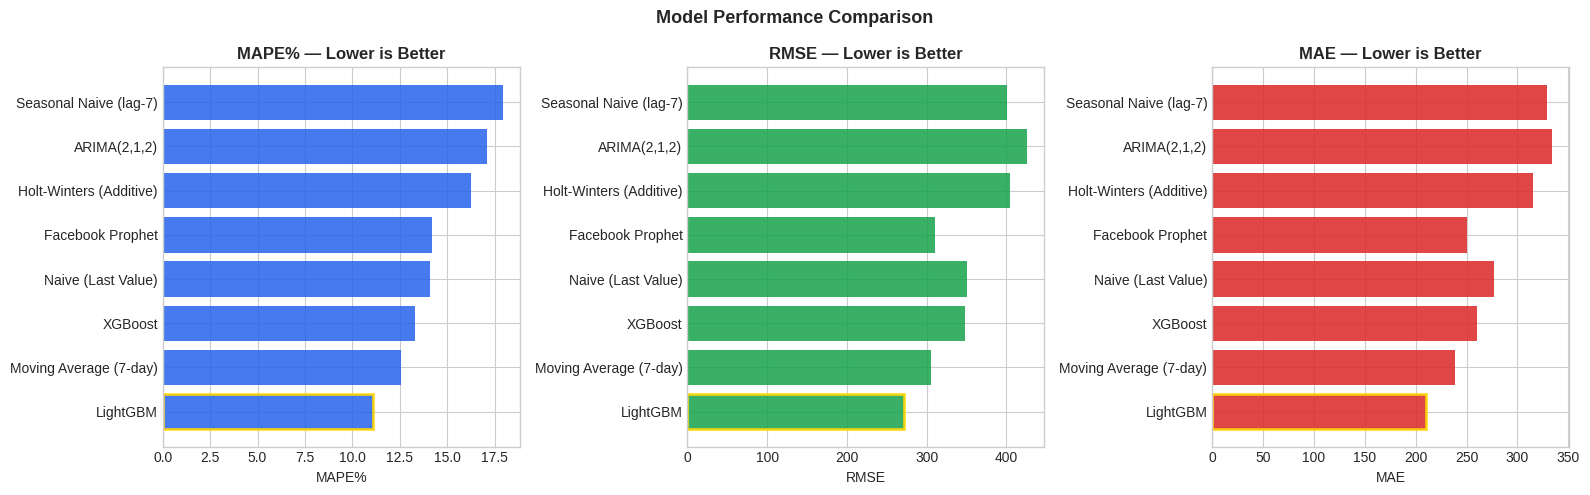

In [59]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Model Performance Comparison', fontsize=13, fontweight='bold')

for ax, metric, color in zip(axes, ['MAPE%','RMSE','MAE'], PALETTE[:3]):
    ax.barh(results_df['Model'], results_df[metric], color=color, alpha=0.85)
    ax.set_title(f'{metric} — Lower is Better', fontweight='bold')
    ax.set_xlabel(metric)
    ax.get_children()[0].set_edgecolor('gold')
    ax.get_children()[0].set_linewidth(2)

plt.tight_layout()
plt.show()

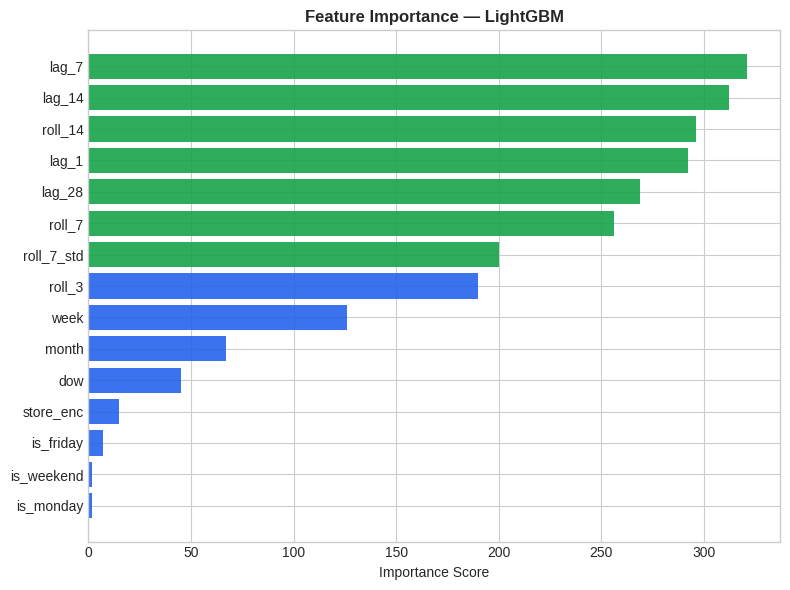

Top 5 most predictive features:
Feature  Importance
 lag_28         269
  lag_1         292
roll_14         296
 lag_14         312
  lag_7         321


In [60]:
feat_imp = pd.DataFrame({
    'Feature':    FEATURE_COLS,
    'Importance': lgb_model.feature_importances_
}).sort_values('Importance')

plt.figure(figsize=(8, 6))
colors_fi = [PALETTE[1] if v > feat_imp['Importance'].median() else PALETTE[0]
             for v in feat_imp['Importance']]
plt.barh(feat_imp['Feature'], feat_imp['Importance'], color=colors_fi, alpha=0.9)
plt.title('Feature Importance — LightGBM', fontsize=12, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print('Top 5 most predictive features:')
print(feat_imp.tail(5)[['Feature','Importance']].to_string(index=False))

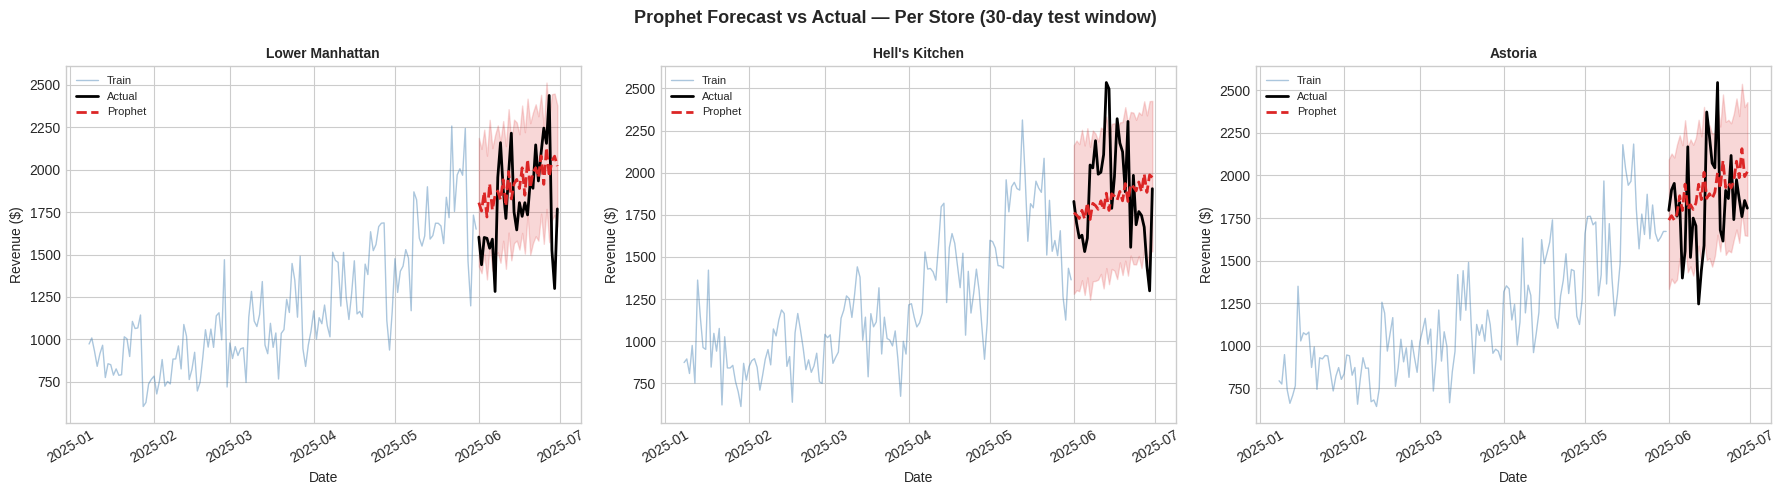

In [61]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Prophet Forecast vs Actual — Per Store (30-day test window)',
             fontsize=13, fontweight='bold')

for i, store in enumerate(STORES):
    d   = prophet_forecasts[store]
    fc  = d['forecast']
    pfc = fc[fc['ds'].isin(d['test_ds'])]

    axes[i].plot(d['train_ds'], d['train_y'],
                 color='steelblue', alpha=0.45, linewidth=1, label='Train')
    axes[i].plot(d['test_ds'], d['test_y'],
                 color='black', linewidth=2, label='Actual')
    axes[i].plot(pfc['ds'], pfc['yhat'].clip(0),
                 color=PALETTE[2], linewidth=2, linestyle='--', label='Prophet')
    axes[i].fill_between(pfc['ds'], pfc['yhat_lower'].clip(0), pfc['yhat_upper'],
                         alpha=0.18, color=PALETTE[2])

    axes[i].set_title(store, fontsize=10, fontweight='bold')
    axes[i].set_xlabel('Date'); axes[i].set_ylabel('Revenue ($)')
    axes[i].legend(fontsize=8)
    axes[i].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

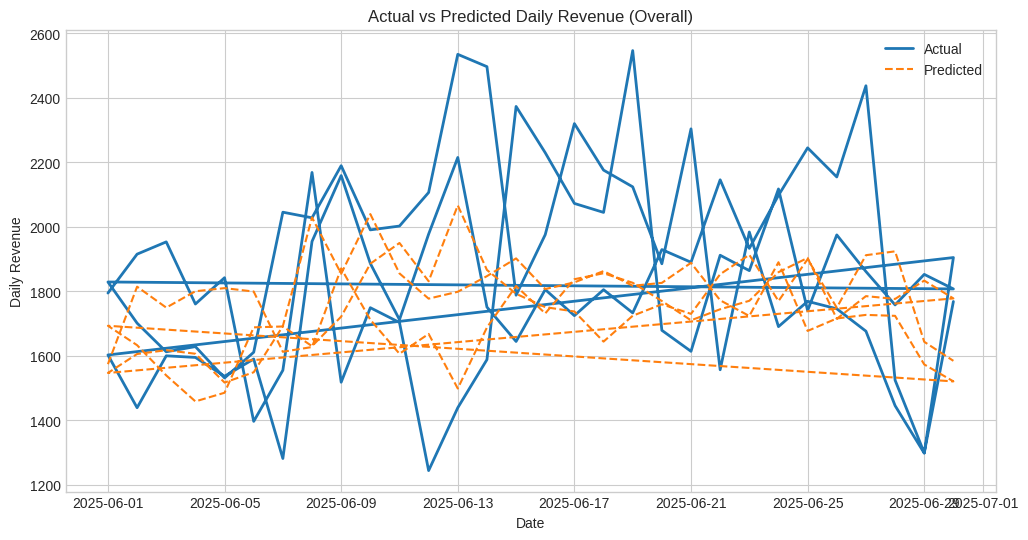

In [62]:
#Overall Forecast vs Actual
plt.figure(figsize=(12,6))
plt.plot(test_df['transaction_date'], y_test, label='Actual', linewidth=2)
plt.plot(test_df['transaction_date'], lgb_pred, label='Predicted', linestyle='--')
plt.legend()
plt.title("Actual vs Predicted Daily Revenue (Overall)")
plt.xlabel("Date")
plt.ylabel("Daily Revenue")
plt.show()

Peak Demand Detection

In [63]:
hourly_store = df.groupby(['store_location','hour'])['revenue'].mean().reset_index()
hourly_store['is_peak'] = hourly_store.groupby('store_location')['revenue'] \
                                       .transform(lambda x: x >= x.quantile(0.8))

print('PEAK HOURS (Top 20%) BY STORE')
print('-'*45)
for store in STORES:
    peaks = sorted(hourly_store[(hourly_store['store_location']==store) &
                                 hourly_store['is_peak']]['hour'].tolist())
    print(f'  {store:<22}: {peaks}')



PEAK HOURS (Top 20%) BY STORE
---------------------------------------------
  Lower Manhattan       : [6, 7, 19]
  Hell's Kitchen        : [9, 11, 20]
  Astoria               : [10, 17, 19]


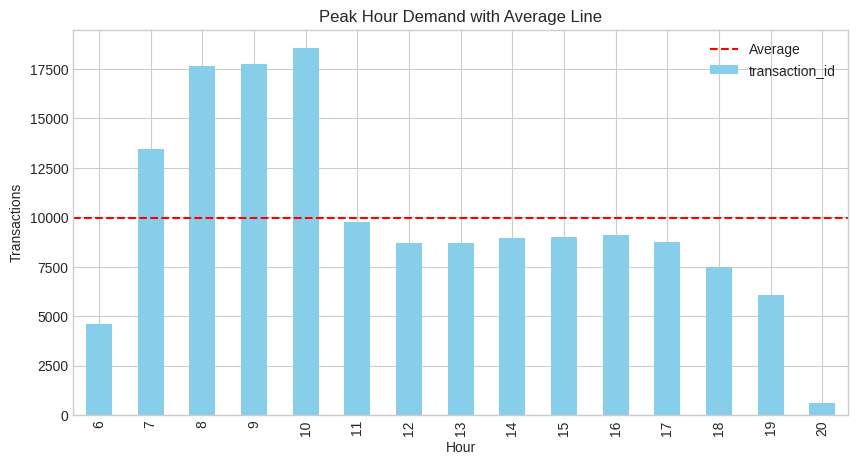

In [64]:
#Enhanced Peak Hour Plot
plt.figure(figsize=(10,5))
hourly_vol.plot(kind='bar', color='skyblue')
plt.axhline(hourly_vol.mean(), color='red', linestyle='--', label='Average')
plt.legend()
plt.title("Peak Hour Demand with Average Line")
plt.xlabel("Hour")
plt.ylabel("Transactions")
plt.show()

In [65]:
daily_ts['is_peak_day'] = daily_ts.groupby('store_location')['daily_revenue'] \
                                   .transform(lambda x: x >= x.quantile(0.8))

print('\n PEAK DAY CONTRIBUTION (top 20% days)')
print('-'*55)
for store in STORES:
    s  = daily_ts[daily_ts['store_location']==store]
    pk = s[s['is_peak_day']]
    pct = 100 * pk['daily_revenue'].sum() / s['daily_revenue'].sum()
    print(f'  {store:<22}: {len(pk)} peak days → {pct:.1f}% of total revenue')


 PEAK DAY CONTRIBUTION (top 20% days)
-------------------------------------------------------
  Lower Manhattan       : 37 peak days → 30.8% of total revenue
  Hell's Kitchen        : 37 peak days → 31.2% of total revenue
  Astoria               : 37 peak days → 30.7% of total revenue


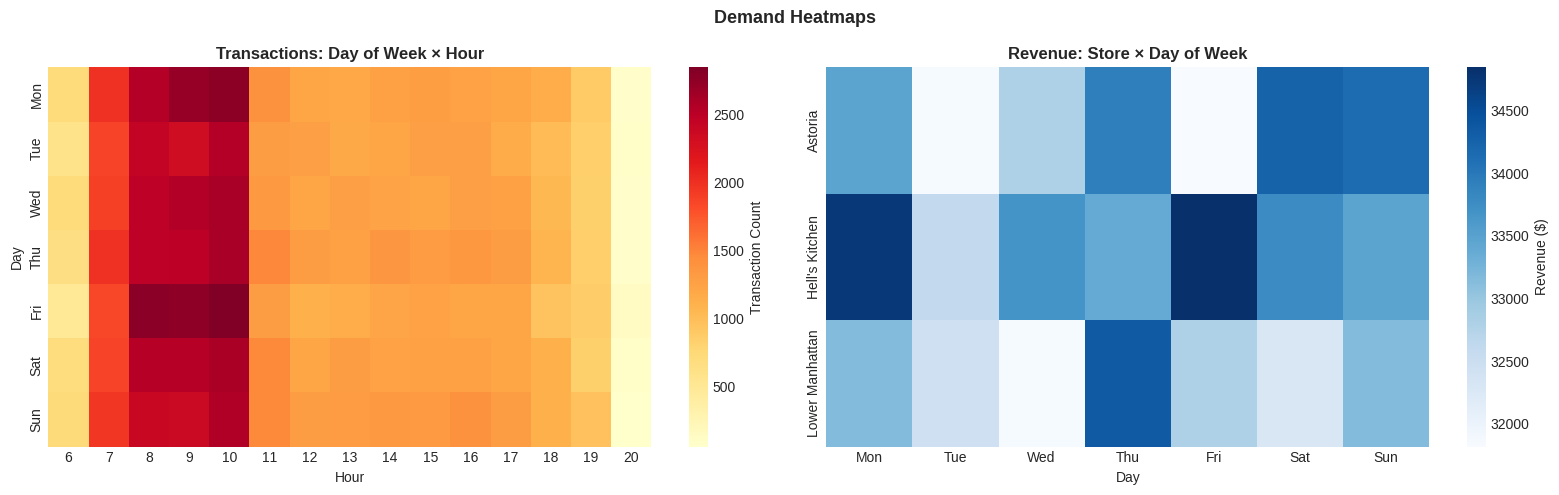

In [66]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Demand Heatmaps', fontsize=13, fontweight='bold')

dow_hour = df.groupby(['day_of_week','hour'])['transaction_id'].count().unstack(fill_value=0)
day_labels = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
sns.heatmap(dow_hour, ax=axes[0], cmap='YlOrRd',
            yticklabels=day_labels, xticklabels=range(6,21),
            cbar_kws={'label':'Transaction Count'})
axes[0].set_title('Transactions: Day of Week × Hour', fontweight='bold')
axes[0].set_xlabel('Hour'); axes[0].set_ylabel('Day')

store_dow = df.groupby(['store_location','day_of_week'])['revenue'].sum().unstack(fill_value=0)
store_dow.columns = day_labels
sns.heatmap(store_dow, ax=axes[1], cmap='Blues', fmt='.0f',
            cbar_kws={'label':'Revenue ($)'})
axes[1].set_title('Revenue: Store × Day of Week', fontweight='bold')
axes[1].set_xlabel('Day'); axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

## Uncertainty & Scenario Analysis

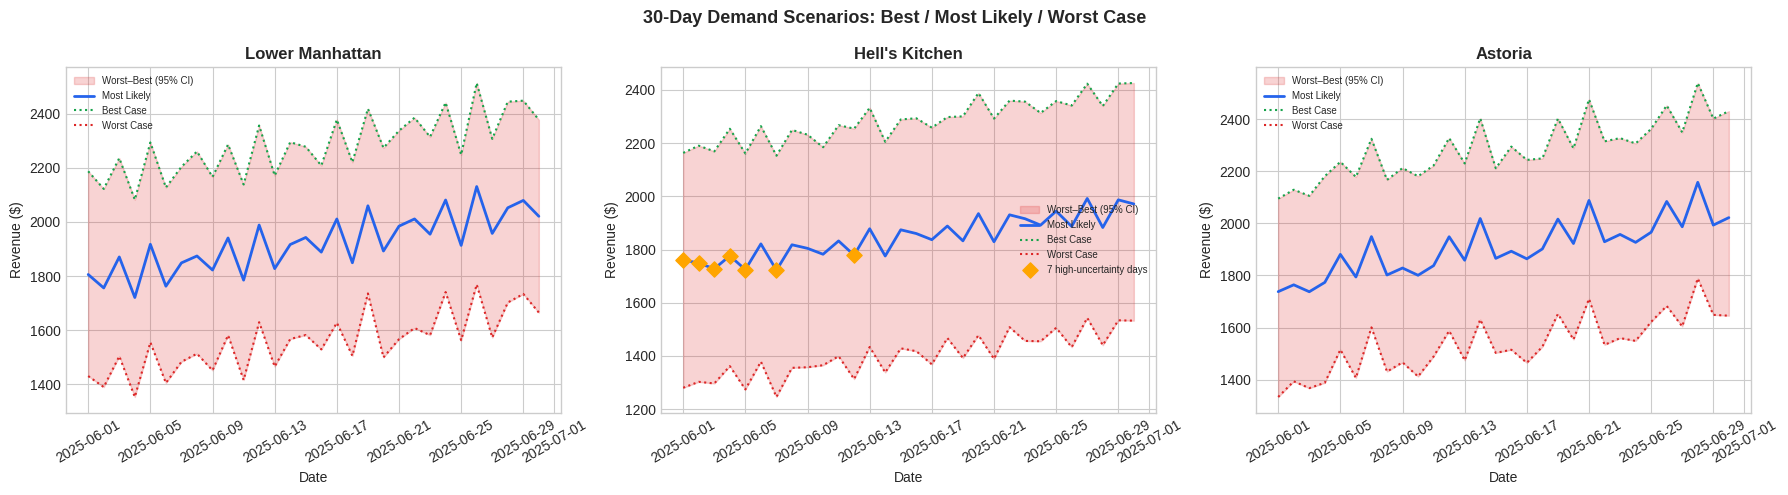


 30-Day Revenue Scenario Summary
Store                  |   Worst Case |  Most Likely |    Best Case
------------------------------------------------------------------
Lower Manhattan        | $    46,725 | $    57,666 | $    68,522
Hell's Kitchen         | $    42,053 | $    55,414 | $    68,548
Astoria                | $    46,050 | $    57,304 | $    68,644


In [67]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('30-Day Demand Scenarios: Best / Most Likely / Worst Case',
             fontsize=13, fontweight='bold')

for i, store in enumerate(STORES):
    d  = prophet_forecasts[store]
    fc = d['forecast'].tail(30)

    axes[i].fill_between(fc['ds'], fc['yhat_lower'].clip(0), fc['yhat_upper'],
                         alpha=0.2, color=PALETTE[2], label='Worst–Best (95% CI)')
    axes[i].plot(fc['ds'], fc['yhat'].clip(0),
                 color=PALETTE[0], linewidth=2, label='Most Likely')
    axes[i].plot(fc['ds'], fc['yhat_upper'],
                 color=PALETTE[1], linestyle=':', linewidth=1.5, label='Best Case')
    axes[i].plot(fc['ds'], fc['yhat_lower'].clip(0),
                 color=PALETTE[2], linestyle=':', linewidth=1.5, label='Worst Case')

    spread = (fc['yhat_upper'] - fc['yhat_lower']) / (fc['yhat'].clip(1))
    spike  = fc[spread > 0.5]
    if len(spike):
        axes[i].scatter(spike['ds'], spike['yhat'].clip(0),
                        color='orange', zorder=5, s=60, marker='D',
                        label=f'{len(spike)} high-uncertainty days')

    axes[i].set_title(store, fontweight='bold')
    axes[i].set_xlabel('Date'); axes[i].set_ylabel('Revenue ($)')
    axes[i].legend(fontsize=7)
    axes[i].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

print('\n 30-Day Revenue Scenario Summary')
print('='*66)
print(f'{"Store":<22} | {"Worst Case":>12} | {"Most Likely":>12} | {"Best Case":>12}')
print('-'*66)
for store in STORES:
    fc     = prophet_forecasts[store]['forecast'].tail(30)
    worst  = fc['yhat_lower'].clip(0).sum()
    likely = fc['yhat'].clip(0).sum()
    best   = fc['yhat_upper'].sum()
    print(f'{store:<22} | ${worst:>10,.0f} | ${likely:>10,.0f} | ${best:>10,.0f}')
print('='*66)

##  KPI Dashboard

In [68]:
best_row = results_df.iloc[0]

forecast_accuracy = best_row['Accuracy%']

p80_thresh = np.percentile(y_test, 80)
peak_mask  = y_test >= p80_thresh
best_preds = [r['preds'] for r in all_results if r['Model']==best_row['Model']][0]
if peak_mask.sum() > 0:
    capture_rate = np.mean(
        np.abs(y_test[peak_mask]-best_preds[peak_mask])/(y_test[peak_mask]+1e-9) < 0.10
    )*100
else:
    capture_rate = 0.0

rev_mape = best_row['MAPE%']

lag7_mape = [r['MAPE%'] for r in all_results if r['Model']=='Seasonal Naive (lag-7)'][0]
lead_time_acc = max(0, 100 - lag7_mape)

store_mapes = []
for store in STORES:
    mask_s = test_df['store_location']==store
    yt_s   = y_test[mask_s]
    yp_s   = lgb_pred[mask_s]
    sm     = np.mean(np.abs(yt_s-yp_s)/(yt_s+1e-9))*100
    store_mapes.append(sm)
forecast_stability = np.std(store_mapes)

print('='*58)
print('KPI DASHBOARD — AFFICIONADO COFFEE ROASTERS')
print('='*58)
print(f'  Forecast Accuracy (%)       : {forecast_accuracy:.1f}%')
print(f'  Peak Demand Capture Rate    : {capture_rate:.1f}%')
print(f'  Revenue Forecast Error (MAPE): {rev_mape:.2f}%')
print(f'  Lead Time Accuracy (7-day)  : {lead_time_acc:.1f}%')
print(f'  Store Forecast Stability    : σ = {forecast_stability:.2f}%  (lower=better)')
print(f'  Best Model                  : {best_row["Model"]}')
print('-'*58)
for store, sm in zip(STORES, store_mapes):
    print(f'    {store:<22}: {sm:.2f}% MAPE')
print('='*58)

KPI DASHBOARD — AFFICIONADO COFFEE ROASTERS
  Forecast Accuracy (%)       : 88.9%
  Peak Demand Capture Rate    : 5.6%
  Revenue Forecast Error (MAPE): 11.07%
  Lead Time Accuracy (7-day)  : 82.1%
  Store Forecast Stability    : σ = 0.12%  (lower=better)
  Best Model                  : LightGBM
----------------------------------------------------------
    Lower Manhattan       : 11.09% MAPE
    Hell's Kitchen        : 11.20% MAPE
    Astoria               : 10.91% MAPE


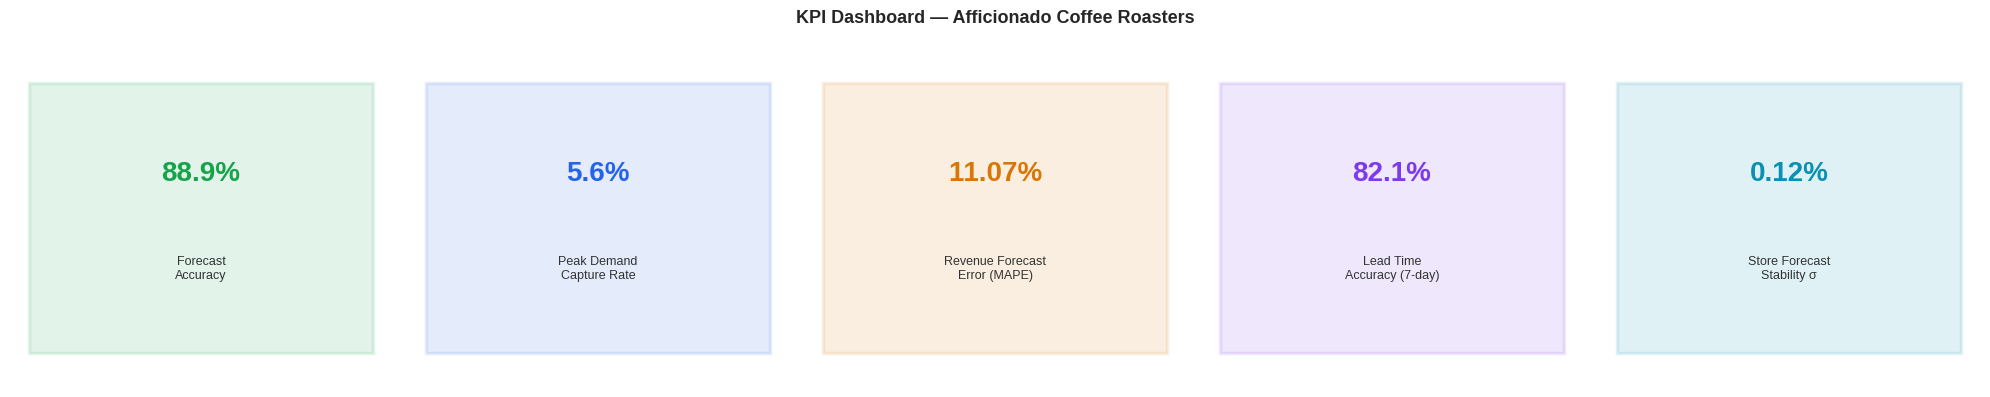

In [69]:
kpis = [
    ('Forecast\nAccuracy',         f'{forecast_accuracy:.1f}%', PALETTE[1]),
    ('Peak Demand\nCapture Rate',  f'{capture_rate:.1f}%',      PALETTE[0]),
    ('Revenue Forecast\nError (MAPE)', f'{rev_mape:.2f}%',      PALETTE[3]),
    ('Lead Time\nAccuracy (7-day)',f'{lead_time_acc:.1f}%',     PALETTE[4]),
    ('Store Forecast\nStability σ',f'{forecast_stability:.2f}%',PALETTE[5]),
]

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
fig.suptitle('KPI Dashboard — Afficionado Coffee Roasters', fontsize=13, fontweight='bold')

for ax, (title, value, color) in zip(axes, kpis):
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    rect = plt.Rectangle((0.05,0.1), 0.9, 0.8, color=color, alpha=0.12,
                          linewidth=2.5, edgecolor=color)
    ax.add_patch(rect)
    ax.text(0.5, 0.63, value, ha='center', va='center',
            fontsize=20, fontweight='bold', color=color)
    ax.text(0.5, 0.35, title, ha='center', va='center',
            fontsize=9,  color='#333333')
    ax.axis('off')

plt.tight_layout()
plt.show()

## 12. Export Results

In [70]:
scenario_rows = []
for store in STORES:
    fc = prophet_forecasts[store]['forecast'].tail(30)
    scenario_rows.append({
        'Store': store,
        'Worst_Case': fc['yhat_lower'].clip(0).sum(),
        'Most_Likely': fc['yhat'].clip(0).sum(),
        'Best_Case': fc['yhat_upper'].sum()
    })
scenario_df=pd.DataFrame(scenario_rows)
scenario_df

,Store,Worst_Case,Most_Likely,Best_Case
0,Lower Manhattan,46725.183964,57666.043955,68521.747808
1,Hell's Kitchen,42052.552162,55413.598238,68547.552645
2,Astoria,46049.967604,57303.765087,68643.912586
